In [11]:
import pickle
from tqdm import tqdm
import pandas as pd
import sys
from concurrent.futures import ProcessPoolExecutor
from rdkit import Chem
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

In [12]:
from sltools import property_tools
from sltools.property_tools import OUT_OF_RANGE, UNDESIRABLE_PATTERNS, CORRECT_PYRROLE, COVALENT_WARHEADS, params, PAINS_catalog

In [13]:
#temp_strs = [str(round(0.1*t,1)) for t in range(5,16)]
iter_strs = ['']# + [f'_{k}' for k in range(1,8)]
temp_strs = ['0.7', '1.0']

sft = []
for temp_str in temp_strs:
    for iter_str in iter_strs:
        with open(f'instr_sft_data{iter_str}/temperature_{temp_str}.pkl', 'rb') as file:
            sft.append(pickle.load(file))

dpo = []
for temp_str in temp_strs:
    for iter_str in iter_strs:
        with open(f'dpo-instr{iter_str}/temperature_{temp_str}.pkl', 'rb') as file:
            dpo.append(pickle.load(file))

In [14]:
from concurrent.futures import ProcessPoolExecutor

def canonicalize(sm):
    mol = Chem.MolFromSmiles(sm)
    if mol is None:
        return sm
    return Chem.MolToSmiles(mol)

def process_k(k):
    row = []
    for ts in range(0, len(temp_strs)*len(iter_strs)):
        m = sft[ts][k]
        n = dpo[ts][k]
        ms = [(canonicalize(item[0]), item[1]) for item in m[1]]
        ns = [(canonicalize(item[0]), item[1]) for item in n[1]]
        col2 = sum(1 for item in set(ms) if item[-1]) / len(m[1]) * 100
        col3 = sum(1 for item in set(ns) if item[-1]) / len(n[1]) * 100
        if ts == 0:
            col1 = m[0][179:-17]
            row = [col1, col2, col3]
        else:
            row += [col2, col3]
    return row

with ProcessPoolExecutor() as executor:
    data = list(tqdm(executor.map(process_k, range(len(sft[0]))), total=len(sft[0])))
    
# Only compute labels once
labels = ['Prompt']
for ts in range(0, len(temp_strs)):
    labels += [f'SFT, T={temp_strs[ts]}', f'DPO, T={temp_strs[ts]}']

100%|██████████| 387/387 [00:08<00:00, 44.10it/s]


In [15]:
#Not putting things into sets, no uniqueness

no_uniq = []

def canonicalize(sm):
    mol = Chem.MolFromSmiles(sm)
    if mol == None:
        return sm
    return Chem.MolToSmiles(mol)

def canonicalize_list(list):
    return [canonicalize(l) for l in list]


for k in tqdm(range(len(sft[0]))):
    for ts in range(len(temp_strs))[::2]:
        m = sft[ts][k]
        n = dpo[ts][k]
        #ms = [(canonicalize(item[0]), item[1]) for item in m[1]]
        #ns = [(canonicalize(item[0]), item[1]) for item in n[1]]
        col2 = sum(1 for item in m[1] if item[-1]==True)/len(m[1])*100
        col3 = sum(1 for item in n[1] if item[-1]==True)/len(n[1])*100
        if ts == 0:
            col1 = m[0][179:-17]
            cols = [col1, col2, col3]
            labels = ['Prompt', 'SFT, T='+temp_strs[ts], 'DPO, T='+temp_strs[ts]]
        else:
            cols += [col2, col3]
            labels += ['SFT, T='+temp_strs[ts], 'DPO, T='+temp_strs[ts]]
    no_uniq.append(cols)

100%|██████████| 387/387 [00:00<00:00, 8991.83it/s]


In [66]:
df = pd.DataFrame(data, columns = labels)

In [78]:
labels

['Prompt', 'SFT, T=0.7', 'DPO, T=0.7', 'SFT, T=1.0', 'DPO, T=1.0']

In [67]:
df

,Prompt,"SFT, T=0.7","DPO, T=0.7","SFT, T=1.0","DPO, T=1.0"
0,exactly 0 H-bond donors,35.058594,66.308594,26.074219,59.472656
1,exactly 1 H-bond donors,24.902344,47.656250,21.484375,44.335938
2,exactly 2 H-bond donors,20.410156,33.203125,21.191406,33.007812
3,exactly 3 H-bond donors,19.531250,15.625000,24.414062,17.578125
4,exactly 4 H-bond donors,22.070312,25.390625,22.363281,23.144531
...,...,...,...,...,...
382,a substructure of O=C(O)Cc1noc2ccccc12,38.378906,71.582031,38.769531,75.976562
383,a substructure of CC(=O)Nc1ccc(C(=O)O)cc1,74.218750,82.324219,75.195312,90.429688
384,a substructure of O=C(O)COc1cccc2ccccc12,36.914062,46.972656,46.777344,47.851562
385,"<= 5 H-bond donors, <= 10 H-bond acceptors, <=...",88.964844,98.730469,81.738281,97.656250


In [16]:
from statistics import stdev, mean

In [17]:
def average_types(data, start_row, end_row, desc):
    print('-----------------------')
    sums = [0 for k in range(1, len(data[0]))]
    for k in range(start_row, end_row):
        print(data[k])
        for l in range(len(data[0])-1):
            sums[l] += data[k][l+1]
    print([desc] + [element / (end_row - start_row) for element in sums])
    mean1 = mean([element / (end_row - start_row) for element in sums][::2])
    #std1 = stdev([element / (end_row - start_row) for element in sums][::2])
    mean2 = mean([element / (end_row - start_row) for element in sums][1::2])
    #std2 = stdev([element / (end_row - start_row) for element in sums][1::2])
    #return [desc, mean1, std1, mean2, std2]
    return [desc] + [element / (end_row - start_row) for element in sums]

In [18]:
reduced_data = []
reduced_data.append(average_types(data, 0, 6, 'Exactly k H-bond donors'))
reduced_data.append(average_types(data, 6, 17, 'Exactly k H-bond acceptors'))
reduced_data.append(average_types(data, 17, 21, '<= k H-bond donors'))
reduced_data.append(average_types(data, 21, 26, '<= k H-bond acceptors'))
reduced_data.append(average_types(data, 26, 30, '<= k molecular weight'))
reduced_data.append(average_types(data, 30, 34, '<= k ClogP'))
reduced_data.append(average_types(data, 34, 37, 'Rotatable bonds in range'))
reduced_data.append(average_types(data, 37, 41, 'Fraction sp3 in range'))
reduced_data.append(average_types(data, 41, 44, 'TPSA in range'))
reduced_data.append(average_types(data, 44, 45, 'Presence of macrocycle'))
reduced_data.append(average_types(data, 45, 46, 'Absence of macrocycle'))
reduced_data.append(average_types(data, 46, 47, 'No bad SMARTS'))
reduced_data.append(average_types(data, 48, 49, 'Absence of Covalent Warheads'))
reduced_data.append(average_types(data, 49, 65, 'Presence of Covalent Warheads'))
reduced_data.append(average_types(data, 65, 385, 'Enamine Substructures'))
reduced_data.append(average_types(data, 385, 386, 'Lipinski rule-of-five'))
reduced_data.append(average_types(data, 386, 387, 'Lipinski rule-of-three'))

-----------------------
['exactly 0 H-bond donors', 35.05859375, 66.30859375, 26.07421875, 59.47265625]
['exactly 1 H-bond donors', 24.90234375, 47.65625, 21.484375, 44.3359375]
['exactly 2 H-bond donors', 20.41015625, 33.203125, 21.19140625, 33.0078125]
['exactly 3 H-bond donors', 19.53125, 15.625, 24.4140625, 17.578125]
['exactly 4 H-bond donors', 22.0703125, 25.390625, 22.36328125, 23.14453125]
['exactly 5 H-bond donors', 20.60546875, 30.76171875, 19.04296875, 29.296875]
['Exactly k H-bond donors', 23.763020833333332, 36.490885416666664, 22.428385416666668, 34.47265625]
-----------------------
['exactly 0 H-bond acceptors', 5.76171875, 65.8203125, 5.56640625, 62.01171875]
['exactly 1 H-bond acceptors', 6.4453125, 38.37890625, 4.19921875, 33.88671875]
['exactly 2 H-bond acceptors', 16.30859375, 58.203125, 10.05859375, 53.22265625]
['exactly 3 H-bond acceptors', 24.8046875, 39.2578125, 22.265625, 45.3125]
['exactly 4 H-bond acceptors', 24.609375, 25.78125, 20.80078125, 37.6953125]
['e

In [19]:
reduced_no_uniq = []
reduced_no_uniq.append(average_types(no_uniq, 0, 6, 'Exactly k H-bond donors'))
reduced_no_uniq.append(average_types(no_uniq, 6, 17, 'Exactly k H-bond acceptors'))
reduced_no_uniq.append(average_types(no_uniq, 17, 21, '<= k H-bond donors'))
reduced_no_uniq.append(average_types(no_uniq, 21, 26, '<= k H-bond acceptors'))
reduced_no_uniq.append(average_types(no_uniq, 26, 30, '<= k molecular weight'))
reduced_no_uniq.append(average_types(no_uniq, 30, 34, '<= k ClogP'))
reduced_no_uniq.append(average_types(no_uniq, 34, 37, 'Rotatable bonds in range'))
reduced_no_uniq.append(average_types(no_uniq, 37, 41, 'Fraction sp3 in range'))
reduced_no_uniq.append(average_types(no_uniq, 41, 44, 'TPSA in range'))
reduced_no_uniq.append(average_types(no_uniq, 44, 45, 'Presence of macrocycle'))
reduced_no_uniq.append(average_types(no_uniq, 45, 46, 'Absence of macrocycle'))
reduced_no_uniq.append(average_types(no_uniq, 46, 47, 'No bad SMARTS'))
reduced_no_uniq.append(average_types(no_uniq, 48, 49, 'Absence of Covalent Warheads'))
reduced_no_uniq.append(average_types(no_uniq, 49, 65, 'Presence of Covalent Warheads'))
reduced_no_uniq.append(average_types(no_uniq, 65, 385, 'Enamine Substructures'))
reduced_no_uniq.append(average_types(no_uniq, 385, 386, 'Lipinski rule-of-five'))
reduced_no_uniq.append(average_types(no_uniq, 386, 387, 'Lipinski rule-of-three'))

-----------------------
['exactly 0 H-bond donors', 35.05859375, 66.30859375]
['exactly 1 H-bond donors', 24.90234375, 47.65625]
['exactly 2 H-bond donors', 20.41015625, 33.203125]
['exactly 3 H-bond donors', 19.62890625, 15.625]
['exactly 4 H-bond donors', 22.16796875, 25.390625]
['exactly 5 H-bond donors', 20.8984375, 30.95703125]
['Exactly k H-bond donors', 23.844401041666668, 36.5234375]
-----------------------
['exactly 0 H-bond acceptors', 5.859375, 72.4609375]
['exactly 1 H-bond acceptors', 6.4453125, 38.76953125]
['exactly 2 H-bond acceptors', 16.30859375, 58.59375]
['exactly 3 H-bond acceptors', 24.90234375, 39.2578125]
['exactly 4 H-bond acceptors', 24.609375, 25.78125]
['exactly 5 H-bond acceptors', 24.12109375, 20.1171875]
['exactly 6 H-bond acceptors', 19.04296875, 35.7421875]
['exactly 7 H-bond acceptors', 20.21484375, 36.23046875]
['exactly 8 H-bond acceptors', 19.82421875, 36.62109375]
['exactly 9 H-bond acceptors', 17.67578125, 30.17578125]
['exactly 10 H-bond acceptor

In [21]:
average_types(no_uniq, 46, 48, 'No bad SMARTS')

-----------------------
['lacks bad SMARTS', 92.67578125, 94.921875]
['has bad SMARTS', 54.8828125, 77.44140625]
['No bad SMARTS', 73.779296875, 86.181640625]


['No bad SMARTS', 73.779296875, 86.181640625]

In [48]:
for r in range(len(reduced_data)):
    d = reduced_data[r]
    n = reduced_no_uniq[r]
    print(f'{d[0]} {round(d[1], 1)} ({round(n[1], 1)}) \\% & {round(d[2], 1)} ({round(n[2], 1)}) \\% &')

Exactly k H-bond donors 23.8 (23.8) \% & 36.5 (36.5) \% &
Exactly k H-bond acceptors 17.9 (18.0) \% & 38.0 (38.7) \% &
<= k H-bond donors 96.6 (96.7) \% & 99.2 (99.3) \% &
<= k H-bond acceptors 96.3 (96.5) \% & 98.3 (98.9) \% &
<= k molecular weight 90.1 (90.2) \% & 97.8 (99.4) \% &
<= k ClogP 89.2 (89.3) \% & 96.8 (97.6) \% &
Rotatable bonds in range 90.0 (90.0) \% & 94.5 (94.6) \% &
Fraction sp3 in range 87.6 (87.6) \% & 96.3 (96.5) \% &
TPSA in range 95.9 (96.1) \% & 98.8 (99.0) \% &
Presence of macrocycle 38.8 (38.8) \% & 58.0 (58.0) \% &
Absence of macrocycle 98.4 (98.5) \% & 98.4 (98.4) \% &
No bad SMARTS 92.5 (92.7) \% & 94.9 (94.9) \% &
Absence of Covalent Warheads 96.4 (96.4) \% & 97.3 (97.3) \% &
Presence of Covalent Warheads 58.3 (59.6) \% & 74.9 (75.3) \% &
Enamine Substructures 51.0 (63.1) \% & 67.7 (75.8) \% &
Lipinski rule-of-five 89.0 (89.1) \% & 98.7 (99.1) \% &
Lipinski rule-of-three 77.5 (79.0) \% & 84.8 (99.4) \% &


In [79]:
for r in range(len(reduced_data)):
    d = reduced_data[r]
    print(f'{d[0]} {round(d[1], 1)} \\% & {round(d[3], 1)} \\% & {round(d[2], 1)} \\% & {round(d[4], 1)} \\% ')

Exactly k H-bond donors 23.8 \% & 22.4 \% & 36.5 \% & 34.5 \% 
Exactly k H-bond acceptors 17.9 \% & 15.0 \% & 38.0 \% & 38.2 \% 
<= k H-bond donors 96.6 \% & 94.4 \% & 99.2 \% & 98.1 \% 
<= k H-bond acceptors 96.3 \% & 90.7 \% & 98.3 \% & 98.4 \% 
<= k molecular weight 90.1 \% & 84.3 \% & 97.8 \% & 98.0 \% 
<= k ClogP 89.2 \% & 85.4 \% & 96.8 \% & 97.7 \% 
Rotatable bonds in range 90.0 \% & 86.7 \% & 94.5 \% & 94.0 \% 
Fraction sp3 in range 87.6 \% & 85.0 \% & 96.3 \% & 95.9 \% 
TPSA in range 95.9 \% & 91.1 \% & 98.8 \% & 98.4 \% 
Presence of macrocycle 38.8 \% & 44.7 \% & 58.0 \% & 57.8 \% 
Absence of macrocycle 98.4 \% & 95.3 \% & 98.4 \% & 97.3 \% 
No bad SMARTS 92.5 \% & 89.6 \% & 94.9 \% & 94.3 \% 
Absence of Covalent Warheads 96.4 \% & 94.2 \% & 97.3 \% & 95.4 \% 
Presence of Covalent Warheads 58.3 \% & 51.0 \% & 74.9 \% & 73.0 \% 
Enamine Substructures 51.0 \% & 51.5 \% & 67.7 \% & 70.1 \% 
Lipinski rule-of-five 89.0 \% & 81.7 \% & 98.7 \% & 97.7 \% 
Lipinski rule-of-three 77.5 

In [73]:
reduced_data

[['Exactly k H-bond donors', 23.095703125, 35.48177083333333],
 ['Exactly k H-bond acceptors', 16.468394886363637, 38.11700994318182],
 ['<= k H-bond donors', 95.49560546875, 98.66943359375],
 ['<= k H-bond acceptors', 93.505859375, 98.330078125],
 ['<= k molecular weight', 87.17041015625, 97.93701171875],
 ['<= k ClogP', 87.34130859375, 97.25341796875],
 ['Rotatable bonds in range', 88.34635416666667, 94.23828125],
 ['Fraction sp3 in range', 86.29150390625, 96.09375],
 ['TPSA in range', 93.53841145833333, 98.6328125],
 ['Presence of macrocycle', 41.748046875, 57.91015625],
 ['Absence of macrocycle', 96.875, 97.8515625],
 ['No bad SMARTS', 91.064453125, 94.62890625],
 ['Absence of Covalent Warheads', 95.3125, 96.337890625],
 ['Presence of Covalent Warheads', 54.656982421875, 73.9593505859375],
 ['Enamine Substructures', 51.256561279296875, 68.91372680664062],
 ['Lipinski rule-of-five', 85.3515625, 98.193359375],
 ['Lipinski rule-of-three', 69.775390625, 89.6484375]]

In [15]:
dpo[0][65]

('### Instruction:\nYou love and excel at generating SMILES strings of drug-like molecules\n\n### Input:\nOutput a SMILES string for a drug like molecule with the following properties: a substructure of Cc1ccc2nc(N)sc2c1:\n\n### Response:\n',
 [('n1(cnc2c(cccc2c1=O)C(Nc1nc2c(s1)cc(C)cc2)=O)C(C(C)(C)C)(C)C(O)=O', True),
  ('C(c1cc(c(cc1C)C)C)Nc1nc2c(s1)cc(C)cc2', True),
  ('N(C(=O)COc1c(cccc1)C(Nc1nc2c(s1)cc(C)cc2)=O)C(C)C', True),
  ('N(c1sc2c(ccc(C)c2)n1)c1ccc(cc1)OCCOCCOCCOCCNC(=O)COc1c2c(cc(c2)C(N(C2CC2)CC)=O)nc(-c2ccc3c(c2)cn[nH]3)c1CC',
   False),
  ('Cc1ccc2nc(NC(N3CCN(CC3)Cc3ccccc3)=NC(=O)C)sc2c1', True),
  ('c1(C)cc2c(nc(s2)NC(c2cc(cnc2Nc2ccccn2)F)=O)cc1C', True),
  ('c1(C)cc2c(cc1C)nc(NC(C(=O)NCC(Nc1ccccc1)=O)=O)s2', True),
  ('O=C(C1CCC(CC1)NC(Nc1nc2c(s1)cc(cc2)C)=O)Oc1cc(cc(c1)C)NC(c1ccc(cc1)Nc1nc2c(cc(cc2)C)s1)=O',
   True),
  ('n1c(N)sc(n1)COc1c(c(Cl)cc(Cl)c1)COc1cc(C(Nc2nc3c(cc(cc3)C)s2)=O)ccc1C',
   True),
  ('C1N(CCOC1)Cc1ccc2nc(NC(=O)Nc3cc(OC)ccc3)sc2c1', True),
  ('C(

In [16]:
reduced_df = pd.DataFrame(reduced_data, columns = labels)

In [17]:
reduced_df

,Prompt,"SFT, T=1.0","DPO, T=1.0"
0,Exactly k H-bond donors,22.428385,34.472656
1,Exactly k H-bond acceptors,15.003551,38.219105
2,<= k H-bond donors,94.384766,98.120117
3,<= k H-bond acceptors,90.722656,98.398438
4,<= k molecular weight,84.252930,98.046875
5,<= k ClogP,85.449219,97.680664
6,Rotatable bonds in range,86.686198,93.977865
7,Fraction sp3 in range,84.985352,95.874023
8,TPSA in range,91.145833,98.437500
9,Presence of macrocycle,44.726562,57.812500


In [18]:
reduced_df

,Prompt,"SFT, T=1.0","DPO, T=1.0"
0,Exactly k H-bond donors,22.428385,34.472656
1,Exactly k H-bond acceptors,15.003551,38.219105
2,<= k H-bond donors,94.384766,98.120117
3,<= k H-bond acceptors,90.722656,98.398438
4,<= k molecular weight,84.252930,98.046875
5,<= k ClogP,85.449219,97.680664
6,Rotatable bonds in range,86.686198,93.977865
7,Fraction sp3 in range,84.985352,95.874023
8,TPSA in range,91.145833,98.437500
9,Presence of macrocycle,44.726562,57.812500


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen, rdMolDescriptors
import warnings
warnings.filterwarnings('ignore')

def calculate_molecular_properties(smiles_list):
    """
    Calculate molecular properties from SMILES strings
    """
    properties = []
    
    for smiles in smiles_list:
        mol = Chem.MolFromSmiles(smiles)
        if mol is not None:
            # Calculate properties
            hbd = rdMolDescriptors.CalcNumHBD(mol)  # H-bond donors
            hba = rdMolDescriptors.CalcNumHBA(mol)  # H-bond acceptors
            mw = Descriptors.MolWt(mol)  # Molecular weight
            logp = Crippen.MolLogP(mol)  # LogP
            
            properties.append({
                'SMILES': smiles,
                'H_bond_donors': hbd,
                'H_bond_acceptors': hba,
                'Molecular_weight': mw,
                'LogP': logp
            })
        else:
            print(f"Warning: Could not parse SMILES: {smiles}")
    
    return pd.DataFrame(properties)

def create_property_plots(df):
    """
    Create histograms and KDE plots for molecular properties
    """
    # Set up the plotting style
    plt.style.use('default')
    sns.set_palette("husl")
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Molecular Property Distributions', fontsize=16, fontweight='bold')
    
    # Plot 1: H-bond donors histogram
    hbd_max = int(df['H_bond_donors'].max())
    hbd_bins = np.arange(-0.5, hbd_max + 1.5, 1)  # Bins centered on integers
    axes[0, 0].hist(df['H_bond_donors'], bins=hbd_bins, align='mid',
                    alpha=0.7, color='skyblue', edgecolor='black', linewidth=1.2)
    axes[0, 0].set_xlabel('Number of H-bond Donors', fontsize=12)
    axes[0, 0].set_xticks(range(hbd_max + 1)) 
    axes[0, 0].set_ylabel('Frequency', fontsize=12)
    axes[0, 0].set_title('Distribution of H-bond Donors', fontsize=14, fontweight='bold')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot 2: H-bond acceptors histogram
    hba_max = int(df['H_bond_acceptors'].max())
    hba_bins = np.arange(-0.5, hba_max + 1.5, 1)  # Bins centered on integers
    axes[0, 1].hist(df['H_bond_acceptors'], bins=hba_bins, align='mid',
                    alpha=0.7, color='lightcoral', edgecolor='black', linewidth=1.2)
    axes[0, 1].set_xlabel('Number of H-bond Acceptors', fontsize=12)
    axes[0, 1].set_xticks(range(hba_max + 1)) 
    axes[0, 1].set_ylabel('Frequency', fontsize=12)
    axes[0, 1].set_title('Distribution of H-bond Acceptors', fontsize=14, fontweight='bold')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot 3: Molecular weight KDE
    sns.kdeplot(data=df, x='Molecular_weight', ax=axes[1, 0], fill=True, 
                color='lightgreen', alpha=0.7, linewidth=2)
    axes[1, 0].set_xlabel('Molecular Weight (Da)', fontsize=12)
    axes[1, 0].set_ylabel('Density', fontsize=12)
    axes[1, 0].set_title('Molecular Weight Distribution (KDE)', fontsize=14, fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Plot 4: LogP KDE
    sns.kdeplot(data=df, x='LogP', ax=axes[1, 1], fill=True, 
                color='gold', alpha=0.7, linewidth=2)
    axes[1, 1].set_xlabel('LogP', fontsize=12)
    axes[1, 1].set_ylabel('Density', fontsize=12)
    axes[1, 1].set_title('LogP Distribution (KDE)', fontsize=14, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3)
    
    # Adjust layout
    plt.tight_layout()
    plt.show()
    
    return fig

def print_summary_statistics(df):
    """
    Print summary statistics for the molecular properties
    """
    print("\n" + "="*60)
    print("MOLECULAR PROPERTY SUMMARY STATISTICS")
    print("="*60)
    
    properties = ['H_bond_donors', 'H_bond_acceptors', 'Molecular_weight', 'LogP']
    
    for prop in properties:
        print(f"\n{prop.replace('_', ' ').title()}:")
        print(f"  Mean: {df[prop].mean():.2f}")
        print(f"  Median: {df[prop].median():.2f}")
        print(f"  Std Dev: {df[prop].std():.2f}")
        print(f"  Min: {df[prop].min():.2f}")
        print(f"  Max: {df[prop].max():.2f}")

In [20]:
ro5 = [s[0] for s in dpo[0][-2][-1]]

Successfully processed 1001 molecules


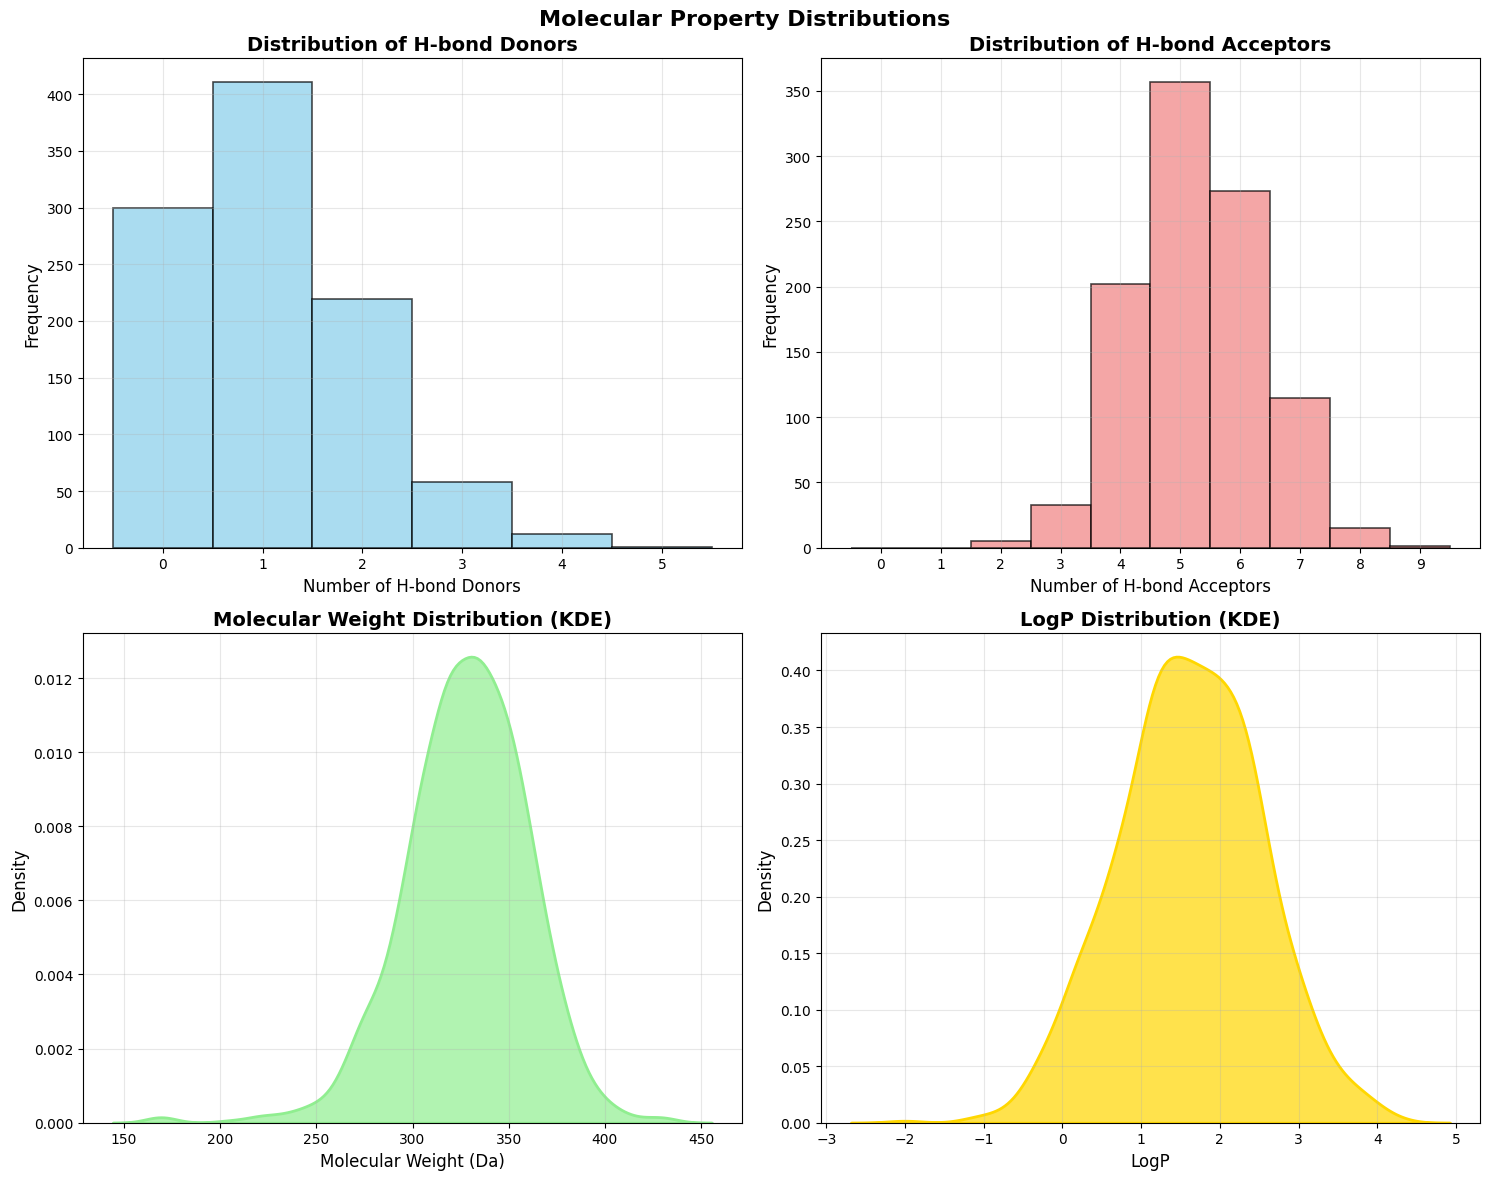


MOLECULAR PROPERTY SUMMARY STATISTICS

H Bond Donors:
  Mean: 1.07
  Median: 1.00
  Std Dev: 0.93
  Min: 0.00
  Max: 5.00

H Bond Acceptors:
  Mean: 5.27
  Median: 5.00
  Std Dev: 1.09
  Min: 2.00
  Max: 9.00

Molecular Weight:
  Mean: 327.90
  Median: 329.49
  Std Dev: 32.05
  Min: 168.24
  Max: 431.52

Logp:
  Mean: 1.61
  Median: 1.62
  Std Dev: 0.91
  Min: -2.01
  Max: 4.24

FIRST 5 MOLECULES - PROPERTY VALUES
                                         SMILES  H_bond_donors  H_bond_acceptors  Molecular_weight     LogP
 c1(OC(C)=O)cc(N(C)C(N2CCN(CC2)C)=O)ccc1OC(C)=O              0                 6           349.387  1.34080
  c1(cc(cc(c1)C(=O)Nc1nocc1)C(=O)N1CCOCC1)C(C)C              1                 5           343.383  2.52270
C1(N(C2(C(N(CC2)Cc2c(C(=O)O)noc2C)=O)CC1)CCO)=O              2                 6           337.332 -0.23298
  N(C(C1(CC1)c1nc(no1)C(C)C)=O)Cc1ncc(o1)C1CCC1              1                 6           330.388  2.79650
        C1(=C(CN2C(COC[C@H]2C)=O)COc2cccc

In [22]:
df = calculate_molecular_properties(ro5)

if not df.empty:
    print(f"Successfully processed {len(df)} molecules")
    
    # Create plots
    fig = create_property_plots(df)
    
    # Print summary statistics
    print_summary_statistics(df)
    
    # Display first few rows of the dataframe
    print("\n" + "="*60)
    print("FIRST 5 MOLECULES - PROPERTY VALUES")
    print("="*60)
    print(df.head().to_string(index=False))
    
else:
    print("No valid molecules found. Please check your SMILES strings.")

In [7]:
from rdkit.Chem import Descriptors

def check_lipinski(smiles):
    """
    Check if a SMILES string satisfies Lipinski's Rule of Five.
    
    Returns True if all rules are satisfied, False otherwise.
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return False
    
    mw = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    hbd = Descriptors.NumHDonors(mol)
    hba = Descriptors.NumHAcceptors(mol)
    
    return (mw <= 500 and 
            logp <= 5 and 
            hbd <= 5 and 
            hba <= 10)

In [8]:
import multiprocessing as mp
from tqdm import tqdm

def process_lines(lines):
    return [line.strip() for line in lines if check_lipinski(line.strip())]

def parallel_process_file(filename, chunk_size=10000):
    chembl_ro5 = []
    with open(filename, 'r') as f:
        pool = mp.Pool(mp.cpu_count())
        chunk = []
        tasks = []
        for line in f:
            chunk.append(line)
            if len(chunk) >= chunk_size:
                tasks.append(pool.apply_async(process_lines, (chunk,)))
                chunk = []
        if chunk:
            tasks.append(pool.apply_async(process_lines, (chunk,)))

        for task in tqdm(tasks):
            chembl_ro5.extend(task.get())

        pool.close()
        pool.join()

    return chembl_ro5

# Usage
chembl_ro5 = parallel_process_file('../sft/chembl_random_smiles.txt')

100%|██████████| 234/234 [00:23<00:00,  9.82it/s]


Successfully processed 1000 molecules


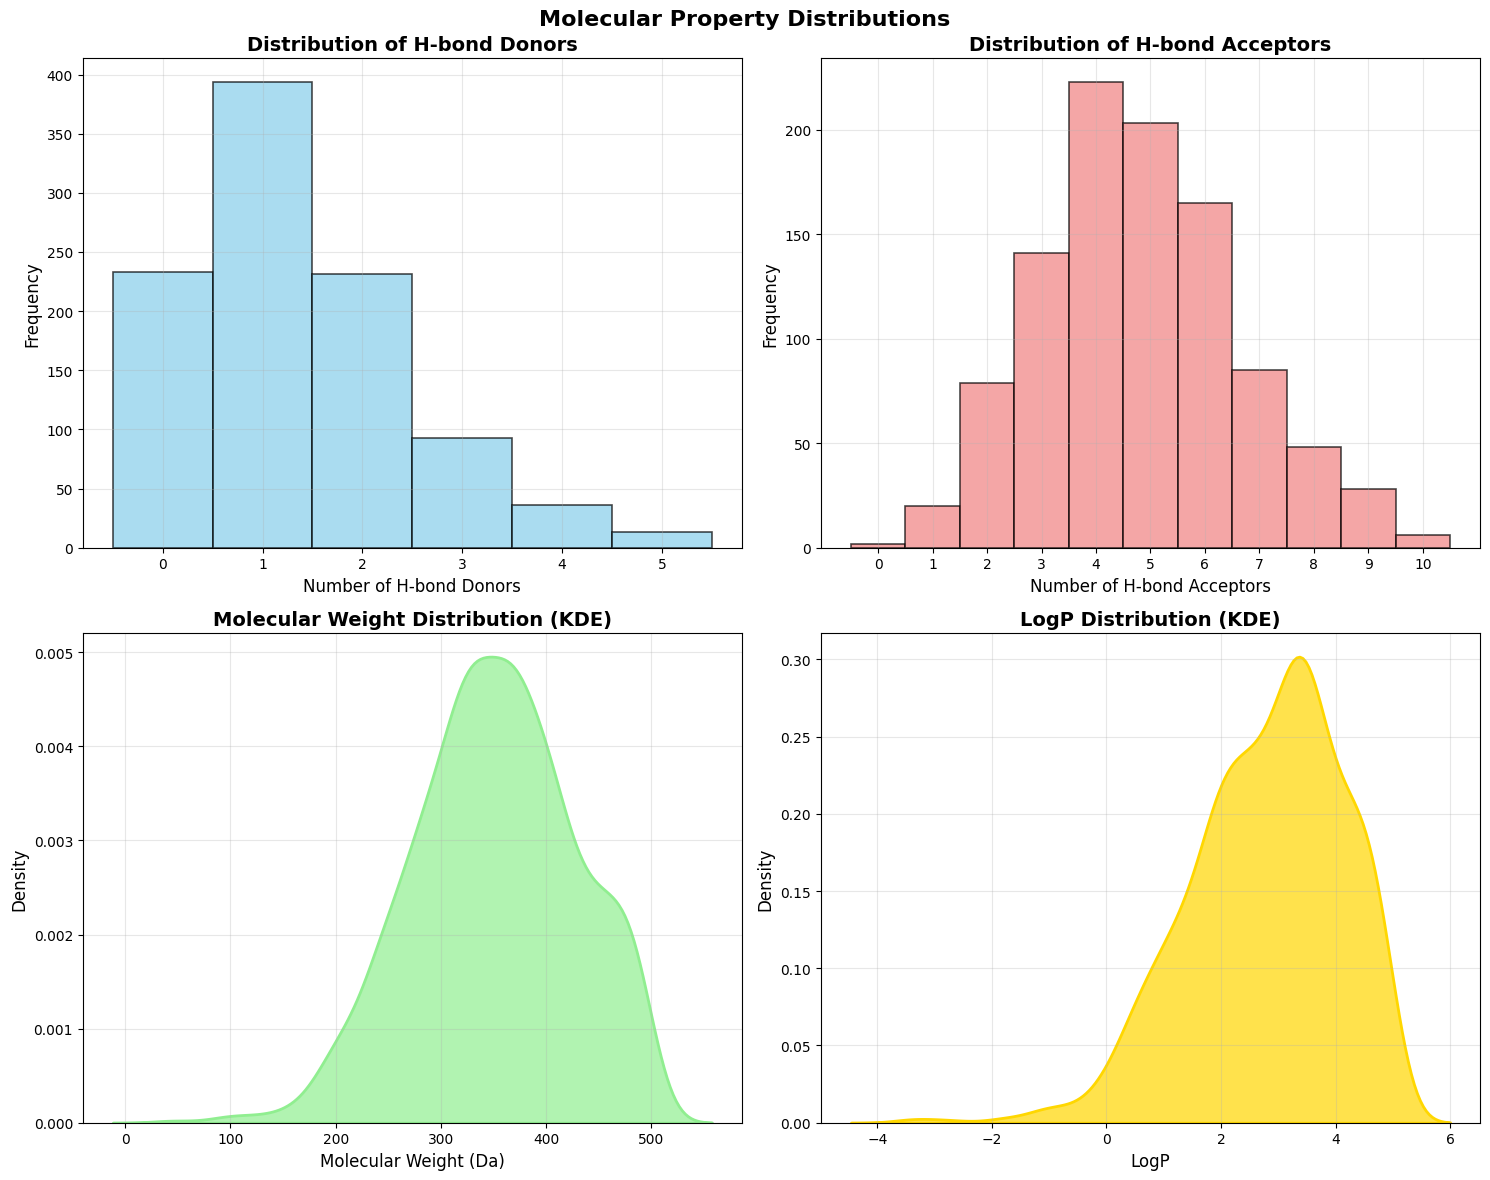


MOLECULAR PROPERTY SUMMARY STATISTICS

H Bond Donors:
  Mean: 1.34
  Median: 1.00
  Std Dev: 1.12
  Min: 0.00
  Max: 5.00

H Bond Acceptors:
  Mean: 4.79
  Median: 5.00
  Std Dev: 1.83
  Min: 0.00
  Max: 10.00

Molecular Weight:
  Mean: 350.90
  Median: 353.16
  Std Dev: 76.75
  Min: 46.01
  Max: 499.58

Logp:
  Mean: 2.80
  Median: 2.98
  Std Dev: 1.33
  Min: -3.46
  Max: 4.99

FIRST 5 MOLECULES - PROPERTY VALUES
                                                                  SMILES  H_bond_donors  H_bond_acceptors  Molecular_weight    LogP
                       c1(Cl)cc(C(F)(F)F)cnc1C(S(=O)(=O)c1ccccc1)/C=N/OC              0                 5           392.786 3.90100
O1[C@@H]2[C@@H]([C@@H](OC)[C@H](O2)[C@@H](NCc2ccc(OC)cc2)CC(N)=O)OC1(C)C              2                 7           380.441 0.92020
                           S(CCCCCC([O-])=O)c1ccncc1Oc1c2ccccc2c(cc1)C#N              0                 6           391.472 4.30118
                     C(C(=O)OC1CC2N(C(CC2)C1)C)(CC)Oc

In [25]:
df = calculate_molecular_properties(list(np.random.choice(chembl_ro5, 1000)))

if not df.empty:
    print(f"Successfully processed {len(df)} molecules")
    
    # Create plots
    fig = create_property_plots(df)
    
    # Print summary statistics
    print_summary_statistics(df)
    
    # Display first few rows of the dataframe
    print("\n" + "="*60)
    print("FIRST 5 MOLECULES - PROPERTY VALUES")
    print("="*60)
    print(df.head().to_string(index=False))
    
else:
    print("No valid molecules found. Please check your SMILES strings.")

In [26]:
lacks_bad_smarts = sft[0][46][1]
counter = 0
for l in lacks_bad_smarts:
    if Chem.MolFromSmiles(l[0]) == None:
        counter += 1
counter

39

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen, rdMolDescriptors
import warnings
warnings.filterwarnings('ignore')

def calculate_molecular_properties(smiles_lists, labels=None):
    """
    Calculate molecular properties from multiple SMILES lists
    
    Parameters:
    smiles_lists: list of lists, where each inner list contains SMILES strings
    labels: list of strings for labeling each dataset (optional)
    """
    if not isinstance(smiles_lists[0], list):
        # Handle single list input for backward compatibility
        smiles_lists = [smiles_lists]
    
    if labels is None:
        labels = [f'Dataset {i+1}' for i in range(len(smiles_lists))]
    
    all_properties = []
    
    for idx, smiles_list in enumerate(smiles_lists):
        properties = []
        
        for smiles in smiles_list:
            mol = Chem.MolFromSmiles(smiles)
            if mol is not None:
                # Calculate properties
                hbd = rdMolDescriptors.CalcNumHBD(mol)  # H-bond donors
                hba = rdMolDescriptors.CalcNumHBA(mol)  # H-bond acceptors
                mw = Descriptors.MolWt(mol)  # Molecular weight
                logp = Crippen.MolLogP(mol)  # LogP
                
                properties.append({
                    'SMILES': smiles,
                    'H_bond_donors': hbd,
                    'H_bond_acceptors': hba,
                    'Molecular_weight': mw,
                    'LogP': logp,
                    'Dataset': labels[idx]
                })
            else: pass
        
        all_properties.extend(properties)
    
    return pd.DataFrame(all_properties)

def create_property_plots(df):
    """
    Create overlapping bar charts and KDE plots for molecular properties from multiple datasets
    """
    # Set up the plotting style
    plt.style.use('default')
    
    # Colorblind-friendly colors: orange, blue, green
    colors = ['#FF8C00', '#1E90FF', '#D3D3D3']  # Dark orange, dodger blue, light gray
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 13))
    #fig.suptitle('Molecular Property Distributions', fontsize=16, fontweight='bold')
    
    datasets = df['Dataset'].unique()
    
    # Plot 1: H-bond donors bar chart
    hbd_max = int(df['H_bond_donors'].max())
    x_positions = np.arange(hbd_max + 1)
    bar_width = 0.25  # Width of each bar
    
    for i, dataset in enumerate(datasets):
        data_subset = df[df['Dataset'] == dataset]
        counts = [len(data_subset[data_subset['H_bond_donors'] == j]) for j in range(hbd_max + 1)]
        
        # Offset bars for each dataset
        offset = (i - len(datasets)/2 + 0.5) * bar_width
        axes[0, 0].bar(x_positions + offset, counts, bar_width, 
                       color=colors[i % len(colors)], alpha=0.7, 
                       label=dataset, edgecolor='black', linewidth=0.5)
    
    axes[0, 0].set_xlabel('Number of H-bond Donors', fontsize=18)
    axes[0, 0].set_xticks(x_positions)
    axes[0, 0].tick_params(axis='x', labelsize=14)
    axes[0, 0].set_yticks([])
    axes[0, 0].set_ylabel('Frequency', fontsize=18)
    axes[0, 0].set_title('Distribution of H-bond Donors', fontsize=20, fontweight='bold')
    axes[0, 0].grid(True, alpha=0.3, axis='y')
    axes[0, 0].legend(fontsize=18)
    
    # Plot 2: H-bond acceptors bar chart
    hba_max = int(df['H_bond_acceptors'].max())
    x_positions = np.arange(hba_max + 1)
    
    for i, dataset in enumerate(datasets):
        data_subset = df[df['Dataset'] == dataset]
        counts = [len(data_subset[data_subset['H_bond_acceptors'] == j]) for j in range(hba_max + 1)]
        
        # Offset bars for each dataset
        offset = (i - len(datasets)/2 + 0.5) * bar_width
        axes[0, 1].bar(x_positions + offset, counts, bar_width, 
                       color=colors[i % len(colors)], alpha=0.7, 
                       label=dataset, edgecolor='black', linewidth=0.5)
    
    axes[0, 1].set_xlabel('Number of H-bond Acceptors', fontsize=18)
    axes[0, 1].set_xticks(x_positions)
    axes[0, 1].tick_params(axis='x', labelsize=14)
    axes[0, 1].set_yticks([])
    axes[0, 1].set_ylabel('Frequency', fontsize=18)
    axes[0, 1].set_title('Distribution of H-bond Acceptors', fontsize=20, fontweight='bold')
    axes[0, 1].grid(True, alpha=0.3, axis='y')
    axes[0, 1].legend(fontsize=18)
    
    # Plot 3: Molecular weight KDE
    for i, dataset in enumerate(datasets):
        data_subset = df[df['Dataset'] == dataset]
        sns.kdeplot(data=data_subset, x='Molecular_weight', ax=axes[1, 0], 
                    fill=True, alpha=0.5, color=colors[i % len(colors)], 
                    linewidth=2, label=dataset)
    
    axes[1, 0].set_xlabel('Molecular Weight (Da)', fontsize=18)
    axes[1, 0].tick_params(axis='x', labelsize=14)
    axes[1, 0].set_ylabel('Density', fontsize=18)
    axes[1, 0].set_yticks([])
    axes[1, 0].set_title('Molecular Weight Distribution (KDE)', fontsize=20, fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].legend(fontsize=18)
    
    # Plot 4: LogP KDE
    for i, dataset in enumerate(datasets):
        data_subset = df[df['Dataset'] == dataset]
        sns.kdeplot(data=data_subset, x='LogP', ax=axes[1, 1], 
                    fill=True, alpha=0.5, color=colors[i % len(colors)], 
                    linewidth=2, label=dataset)
    
    axes[1, 1].set_xlabel('LogP', fontsize=18)
    axes[1, 1].tick_params(axis='x', labelsize=14)
    axes[1, 1].set_ylabel('Density', fontsize=18)
    axes[1, 1].set_yticks([])
    axes[1, 1].set_title('LogP Distribution (KDE)', fontsize=20, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].legend(fontsize=18)
    
    # Adjust layout
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.3)
    plt.savefig('lipinski_ro5_properties.png', dpi=600, bbox_inches='tight')
    plt.show()
    
    return fig

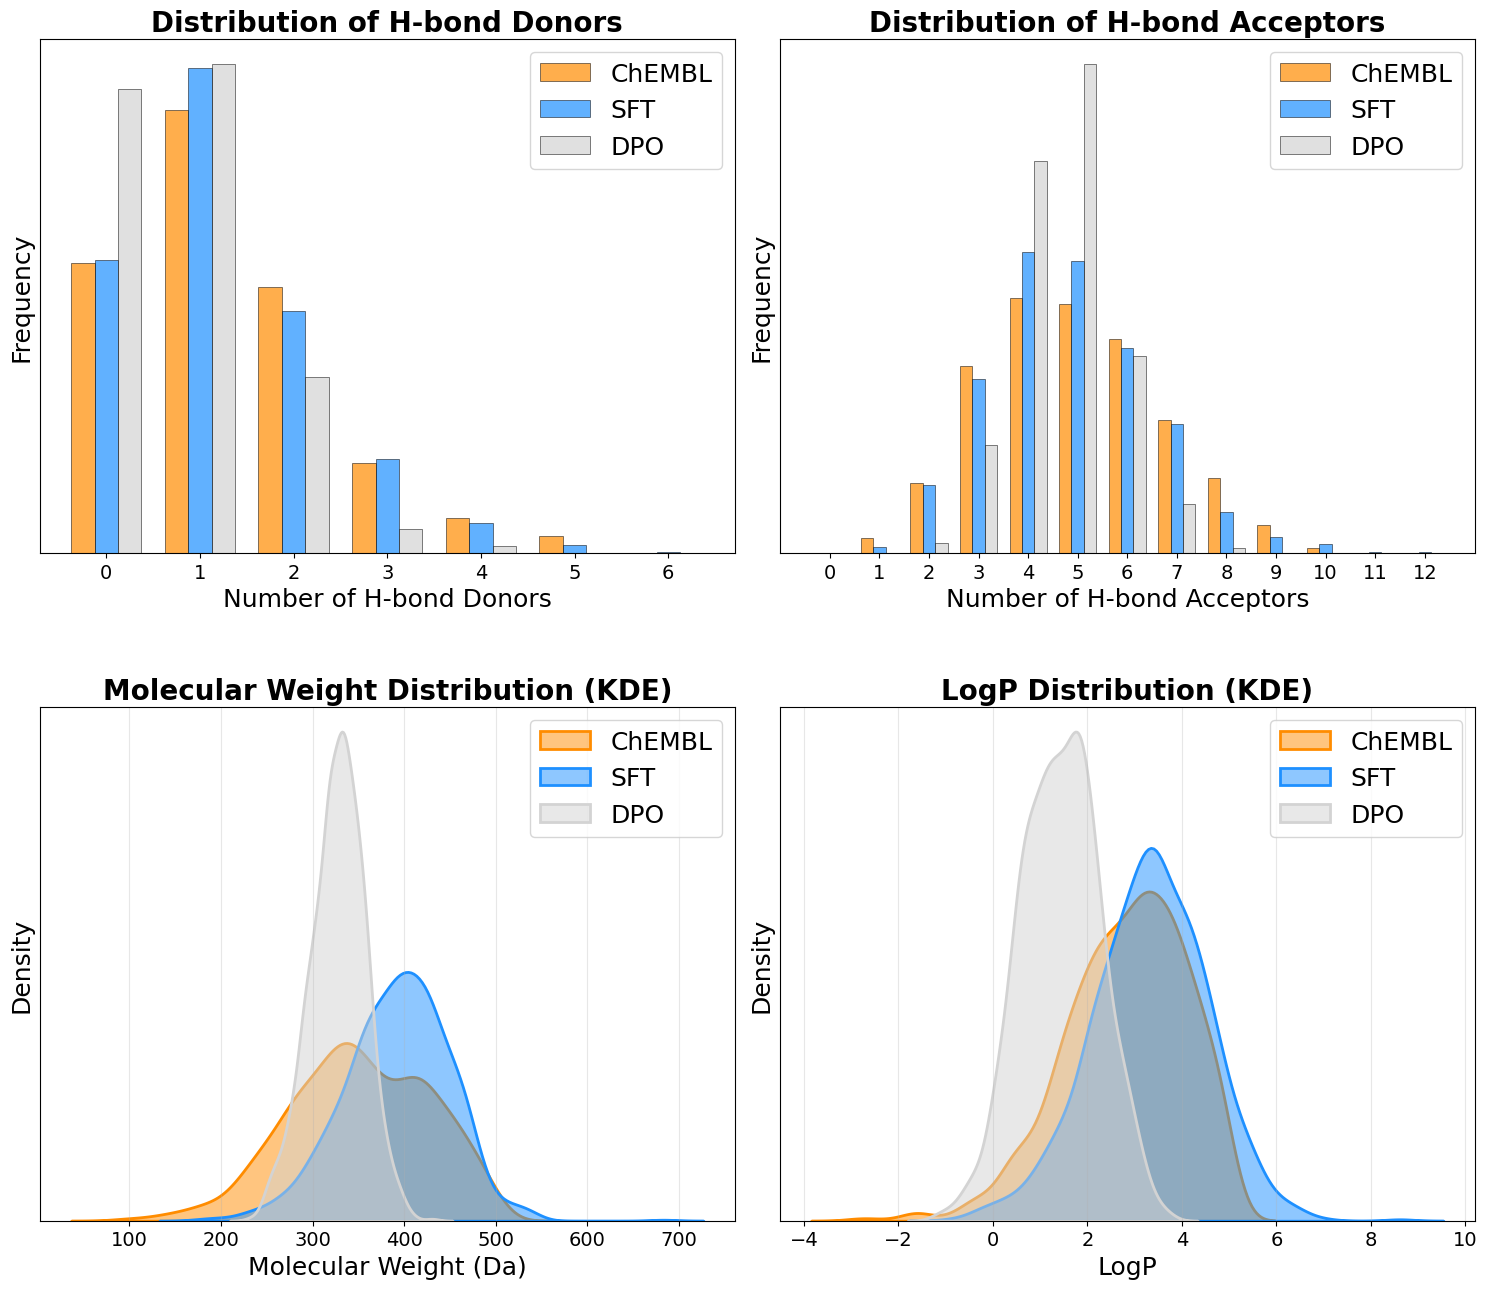

In [10]:
ro5 = [s[0] for s in dpo[0][-2][-1]]
ro5_sft = [s[0] for s in sft[0][-2][-1]]

df = calculate_molecular_properties([list(np.random.choice(chembl_ro5, 1000)), ro5_sft, ro5], 
                                   labels=['ChEMBL', 'SFT', 'DPO'])

# Create plots
fig = create_property_plots(df)


In [12]:
good_phrases = ["<= 3 H-bond donors", "<= 3 H-bond acceptors", "<= 300 Molecular weight", "<= 3 LogP"]
bad_phrases = ["substructure", "formula", "Fraction", "covalent", "macrocycle", "TPSA", "Rotatable", "SMARTS"]#+["H-bond donors", "H-bond acceptors", "Molecular weight", "LogP"]

no_stuff = []
with open('../sft/random_smiles.jsonl') as f:
    for line in tqdm(f):
        if all([g in line for g in good_phrases]) and not any([g in line for g in bad_phrases]):
            no_stuff.append(line)
len(no_stuff)

2330226it [00:04, 505201.89it/s]


0

In [54]:
no_stuff

['{"instruction": "You love and excel at generating SMILES strings of drug-like molecules", "input": "Output a SMILES string for a drug-like molecule with the following properties: <= 10 H-bond acceptors, <= 5 H-bond donors, <= 500 Molecular weight, <= 5 LogP:", "output": "n1ccc(c(c1)C)-c1cnn(-c2ccccc2)c1"}\n',
 '{"instruction": "You love and excel at generating SMILES strings of drug-like molecules", "input": "Output a SMILES string for a drug-like molecule with the following properties: <= 5 LogP, <= 5 H-bond donors, <= 10 H-bond acceptors, <= 500 Molecular weight:", "output": "C1CCN(C1)c1cc2n(cc(-c3cc(c(cc3OC)OC)Br)n2)cc1"}\n',
 '{"instruction": "You love and excel at generating SMILES strings of drug-like molecules", "input": "Output a SMILES string for a drug-like molecule with the following properties: <= 5 H-bond donors, <= 10 H-bond acceptors, <= 500 Molecular weight, <= 5 LogP:", "output": "c1(c(C)ccc(c1)C(=O)Nc1noc(C(C)(C)C)c1)-n1nnc(c1)-c1cncc(c1)NC(C)C"}\n',
 '{"instruction

In [32]:
sft[0][-2][0]

'### Instruction:\nYou love and excel at generating SMILES strings of drug-like molecules\n\n### Input:\nOutput a SMILES string for a drug like molecule with the following properties: <= 5 H-bond donors, <= 10 H-bond acceptors, <= 500 Molecular weight, <= 5 LogP:\n\n### Response:\n'